#📌 Extracão

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [79]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
df = response.json()
df = pd.json_normalize(df)
df_original = df.copy()
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformação

In [85]:
for coluna in df.columns:
  print(pd.unique(df[coluna]))
df.info()

[False  True]
['Female' 'Male']
[False  True]
[ True False]
[ True False]
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
[ True False]
['DSL' 'Fiber optic' 'No']
['One year' 'Month-to-month' 'Two year']
[ True False]
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
[65.6  59.9  73.9  ... 91.75 68.8  67.85]
[ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
[ 9.04420732  9.05509182  3.80040595 ...  1.84393638 68.20412675
 62.84067797]
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Churn                     7043 non-null   bool   
 1   customer.gender           7043 non-null   object 
 2   customer.Seni

In [81]:
df['account.Charges.Total'] = df['account.Charges.Total'].replace(' ', np.nan)
df['account.Charges.Total'] = df['account.Charges.Total'].astype(np.float64)
nan_indices = df[df['account.Charges.Total'].isna()].index
for i in nan_indices:
  df.loc[i, 'account.Charges.Total'] = 0


df['contas_diarias'] = df['account.Charges.Total'] / df['account.Charges.Monthly']

In [82]:
df['Churn'] = df['Churn'].replace('', np.nan)
df.dropna(subset=['Churn'], inplace=True)

In [83]:
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].apply(lambda x: True if x == 1 else False)
df[['Churn', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'account.PaperlessBilling']] = df[['Churn', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'account.PaperlessBilling']].map(lambda x: True if x == 'Yes' else False)

In [84]:
df = df.drop(['customerID','phone.MultipleLines', 'internet.OnlineSecurity', 'internet.DeviceProtection', 'internet.OnlineBackup', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies'], axis=1)
display(df.head())

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,internet.InternetService,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,False,Female,False,True,True,9,True,DSL,One year,True,Mailed check,65.6,593.30,9.044207
1,False,Male,False,False,False,9,True,DSL,Month-to-month,False,Mailed check,59.9,542.40,9.055092
2,True,Male,False,False,False,4,True,Fiber optic,Month-to-month,True,Electronic check,73.9,280.85,3.800406
3,True,Male,True,True,False,13,True,Fiber optic,Month-to-month,True,Electronic check,98.0,1237.85,12.631122
4,True,Female,True,True,False,3,True,Fiber optic,Month-to-month,True,Mailed check,83.9,267.40,3.187128


In [86]:
df = pd.get_dummies(df)
display(df.head())

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,contas_diarias,...,internet.InternetService_DSL,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,False,False,True,True,9,True,True,65.6,593.30,9.044207,...,True,False,False,False,True,False,False,False,False,True
1,False,False,False,False,9,True,False,59.9,542.40,9.055092,...,True,False,False,True,False,False,False,False,False,True
2,True,False,False,False,4,True,True,73.9,280.85,3.800406,...,False,True,False,True,False,False,False,False,True,False
3,True,True,True,False,13,True,True,98.0,1237.85,12.631122,...,False,True,False,True,False,False,False,False,True,False
4,True,True,True,False,3,True,True,83.9,267.40,3.187128,...,False,True,False,True,False,False,False,False,False,True


In [87]:
churn_counts = df['Churn'].value_counts()
churn_proportions = churn_counts / len(df)

print("Proporção de clientes que evadiram (Churn=True) vs. Clientes que permaneceram ativos (Churn=False):")
print(churn_proportions)

if churn_proportions[True] < 0.2 or churn_proportions[False] < 0.2:
    print("\nExiste um desequilíbrio significativo entre as classes.")
else:
    print("\nNão há um desequilíbrio significativo entre as classes.")

Proporção de clientes que evadiram (Churn=True) vs. Clientes que permaneceram ativos (Churn=False):
Churn
False    0.73463
True     0.26537
Name: count, dtype: float64

Não há um desequilíbrio significativo entre as classes.


# 🎯 Correlação e Seleção de Variáveis


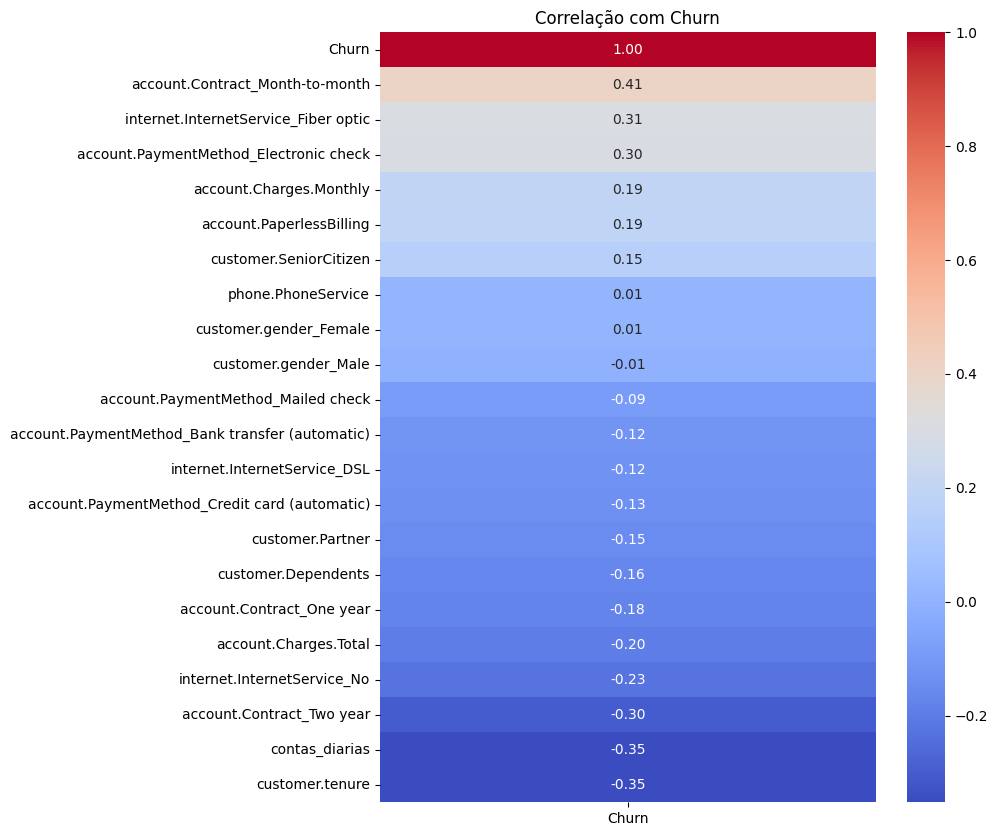

In [88]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Filter for the 'Churn' row
churn_correlation = correlation_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Display the correlation with Churn
plt.figure(figsize=(8, 10))
sns.heatmap(churn_correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação com Churn')
plt.show()

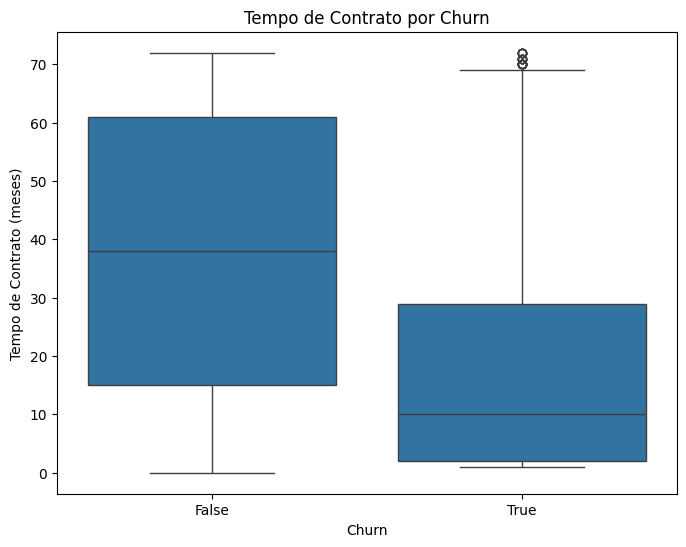

In [92]:
# Boxplot para visualizar a relação entre customer.tenure e Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='customer.tenure', data=df)
plt.title('Tempo de Contrato por Evasão')
plt.xlabel('Evasão')
plt.ylabel('Tempo de Contrato (meses)')
plt.show()

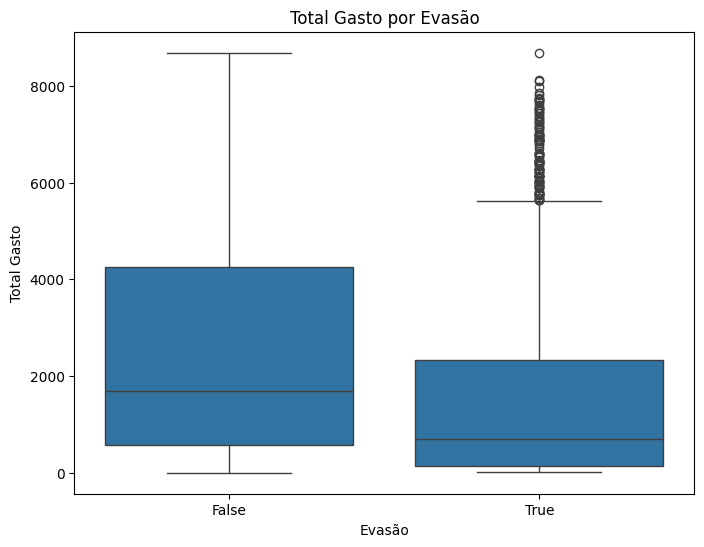

In [95]:
# Boxplot para visualizar a relação entre account.Charges.Total e Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='account.Charges.Total', data=df)
plt.title('Total Gasto por Evasão')
plt.xlabel('Evasão')
plt.ylabel('Total Gasto')
plt.show()

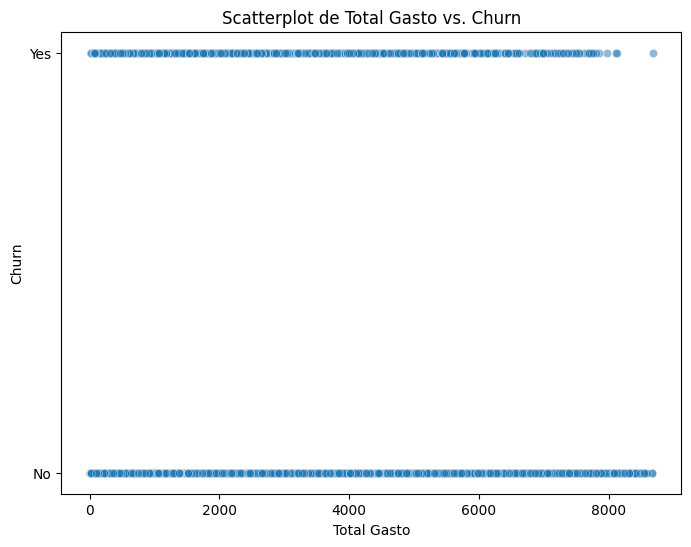

In [96]:
# Scatterplot para visualizar a relação entre account.Charges.Total e Churn
plt.figure(figsize=(8, 6))
sns.scatterplot(x='account.Charges.Total', y='Churn', data=df, alpha=0.5)
plt.title('Scatterplot de Total Gasto vs. Churn')
plt.xlabel('Total Gasto')
plt.ylabel('Churn')
plt.yticks([0, 1], ['No', 'Yes']) # Assuming Churn is boolean (False=0, True=1)
plt.show()

# 🤖 Modelagem Preditiva

In [101]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4930, 21)
Shape of X_test: (2113, 21)
Shape of y_train: (4930,)
Shape of y_test: (2113,)


In [103]:
# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Classifier Model Trained")

Random Forest Classifier Model Trained


In [109]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier Model Trained")

Decision Tree Classifier Model Trained


--- Métricas de Avaliação para Random Forest ---
Acurácia: 0.7795
Precisão: 0.5968
Recall: 0.4755
F1-score: 0.5293
------------------------------


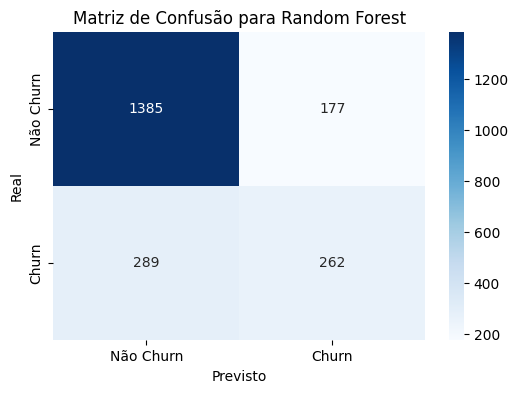



--- Métricas de Avaliação para Árvore de Decisão ---
Acurácia: 0.7307
Precisão: 0.4843
Recall: 0.5027
F1-score: 0.4933
------------------------------


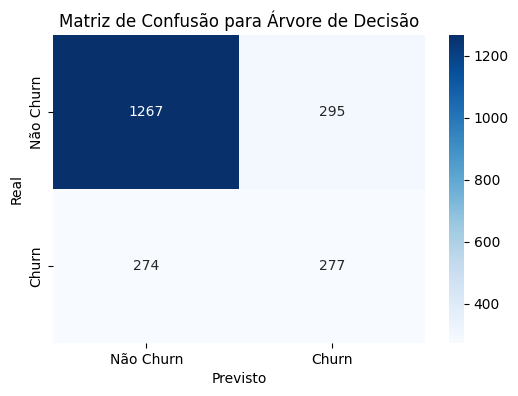

In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluates a model and prints the metrics and confusion matrix."""
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- Métricas de Avaliação para {model_name} ---")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("-" * 30)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Churn', 'Churn'], yticklabels=['Não Churn', 'Churn'])
    plt.title(f'Matriz de Confusão para {model_name}')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()
    print("\n") # Add a newline for better separation

# Evaluate Random Forest model
evaluate_model(rf_model, X_test, y_test, "Random Forest")

# Evaluate Decision Tree model
evaluate_model(dt_model, X_test, y_test, "Árvore de Decisão")

---
### Análise Crítica e Comparação dos Modelos

Nesta seção, realizamos uma análise crítica e comparativa entre dois modelos de aprendizado de máquina: **Random Forest** e **Árvore de Decisão**, avaliando seu desempenho com base em métricas de classificação.

#### Acurácia
O modelo **Random Forest** (0.7795) obteve uma acurácia superior à **Árvore de Decisão** (0.7307). Isso indica que o Random Forest classificou corretamente uma porcentagem maior de instâncias no conjunto de dados de teste.

#### Precisão
A **Precisão** do **Random Forest** (0.5968) também foi maior que a da **Árvore de Decisão** (0.4843). Isso significa que, quando o modelo Random Forest previu a ocorrência de Churn, sua previsão estava correta com mais frequência.

#### Recall
A **Árvore de Decisão** (0.5027) apresentou um Recall ligeiramente maior que o **Random Forest** (0.4755). O Recall mede a capacidade do modelo de identificar corretamente todas as instâncias positivas (neste caso, clientes que deram Churn).

#### F1-score
O **F1-score**, que é a média harmônica da precisão e do recall, foi maior para o **Random Forest** (0.5293) em comparação com a **Árvore de Decisão** (0.4933). Isso sugere que o Random Forest alcançou um melhor equilíbrio entre precisão e recall.

#### Matriz de Confusão
* **Random Forest**: Teve menos Falsos Positivos (177) do que a Árvore de Decisão (295), o que reforça sua maior precisão. No entanto, apresentou um número ligeiramente maior de Falsos Negativos (289), o que se alinha com seu recall um pouco menor.
* **Árvore de Decisão**: Apresentou mais Falsos Positivos, mas menos Falsos Negativos em comparação com o Random Forest.

---
### Conclusão

Com base nas métricas analisadas, o modelo **Random Forest** demonstra um desempenho geral superior para este conjunto de dados, apresentando maior acurácia, precisão e F1-score.

Importância das Variáveis no Modelo Random Forest:
contas_diarias                                     0.185187
account.Charges.Monthly                            0.177863
account.Charges.Total                              0.174625
customer.tenure                                    0.121442
account.Contract_Month-to-month                    0.065804
internet.InternetService_Fiber optic               0.032257
account.PaymentMethod_Electronic check             0.030005
account.PaperlessBilling                           0.025733
customer.Partner                                   0.022164
customer.SeniorCitizen                             0.019680
account.Contract_Two year                          0.018719
internet.InternetService_No                        0.017587
customer.Dependents                                0.017172
customer.gender_Female                             0.014506
customer.gender_Male                               0.014490
internet.InternetService_DSL                     

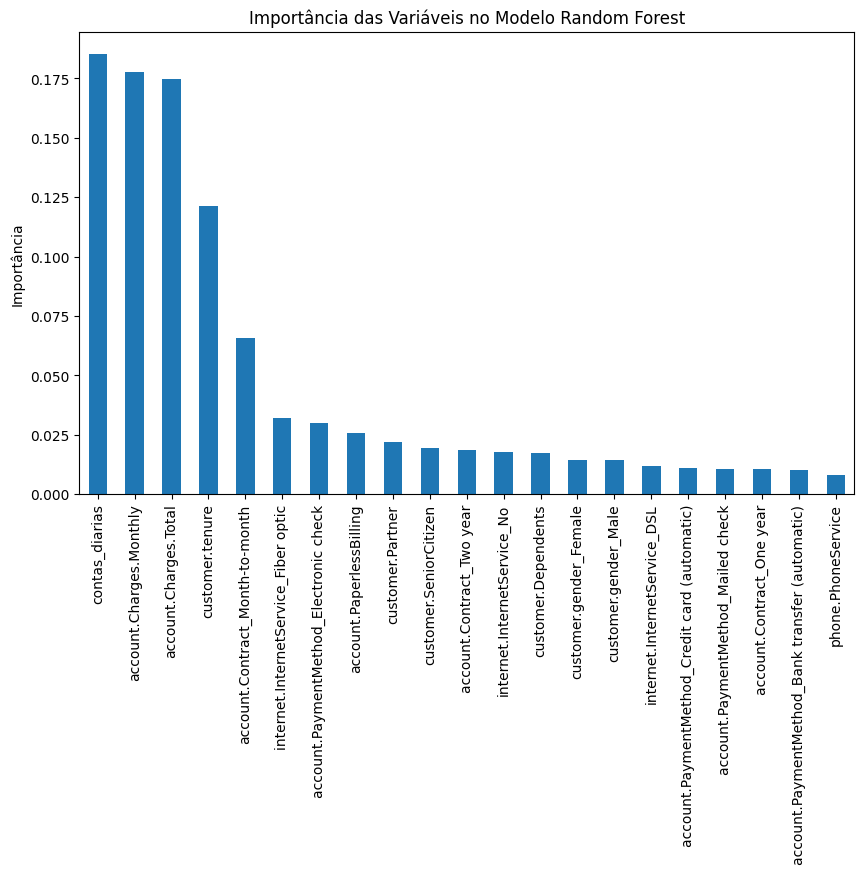

In [111]:
# Get feature importances from Random Forest model
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Importância das Variáveis no Modelo Random Forest:")
print(rf_feature_importances)

# Plot feature importances for Random Forest
plt.figure(figsize=(10, 6))
rf_feature_importances.plot(kind='bar')
plt.title('Importância das Variáveis no Modelo Random Forest')
plt.ylabel('Importância')
plt.show()


Importância das Variáveis no Modelo Árvore de Decisão:
account.Charges.Monthly                            0.207361
contas_diarias                                     0.193472
account.Contract_Month-to-month                    0.170457
account.Charges.Total                              0.154280
customer.tenure                                    0.056918
internet.InternetService_Fiber optic               0.046050
account.PaperlessBilling                           0.029859
customer.SeniorCitizen                             0.018502
customer.Dependents                                0.018459
customer.Partner                                   0.015297
customer.gender_Female                             0.013992
account.PaymentMethod_Electronic check             0.013048
account.PaymentMethod_Mailed check                 0.010455
customer.gender_Male                               0.009551
account.PaymentMethod_Credit card (automatic)      0.009456
internet.InternetService_No                 

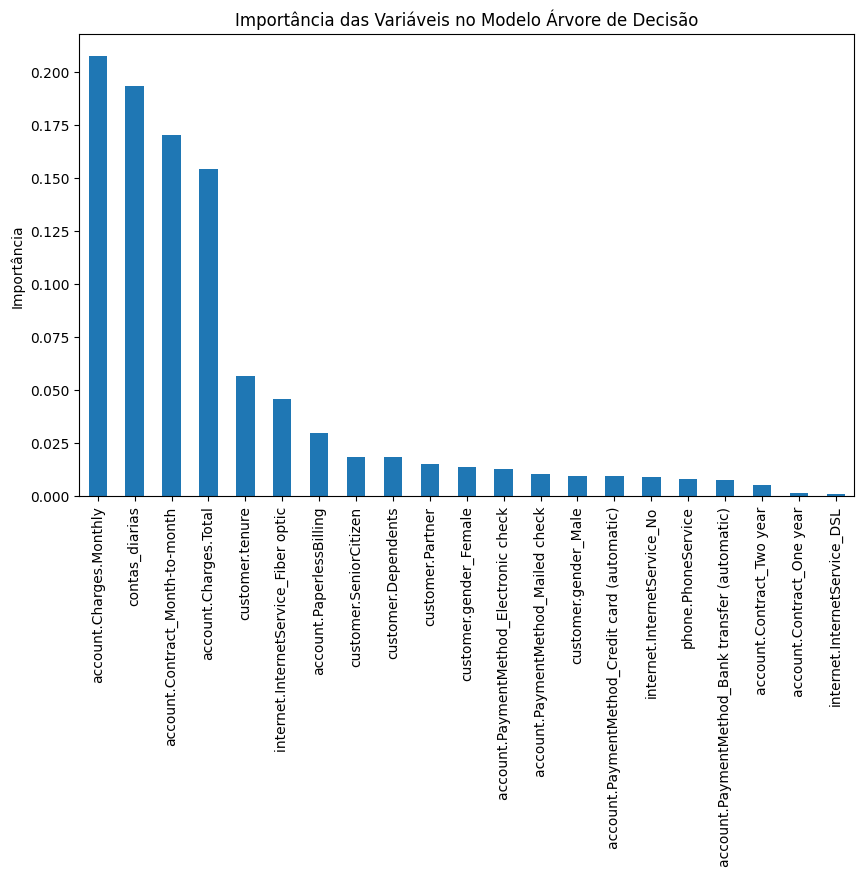

In [112]:
# Get feature importances from Decision Tree model
dt_feature_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\nImportância das Variáveis no Modelo Árvore de Decisão:")
print(dt_feature_importances)

# Plot feature importances for Decision Tree
plt.figure(figsize=(10, 6))
dt_feature_importances.plot(kind='bar')
plt.title('Importância das Variáveis no Modelo Árvore de Decisão')
plt.ylabel('Importância')
plt.show()

# 📋  Interpretação e Conclusões

Com base na análise dos dados, no treinamento e avaliação dos modelos Random Forest e Árvore de Decisão, e na análise da importância das variáveis, podemos tirar as seguintes conclusões e insights de negócios:

**Desempenho dos Modelos:**

*   Ambos os modelos (Random Forest e Árvore de Decisão) foram capazes de prever a evasão de clientes com uma acurácia razoável.
*   O modelo **Random Forest** demonstrou um desempenho geral superior em comparação com a Árvore de Decisão, apresentando maior acurácia, precisão e F1-score no conjunto de teste. Isso sugere que a abordagem de ensemble do Random Forest, que combina várias árvores de decisão, ajudou a melhorar a capacidade de generalização do modelo.
*   A **Matriz de Confusão** revelou que, embora o Random Forest tenha uma precisão maior (menos falsos positivos), a Árvore de Decisão teve um Recall ligeiramente maior (identificou um pouco mais de clientes que realmente evadiram). A escolha do modelo ideal pode depender do custo relativo de falsos positivos versus falsos negativos para o negócio.

**Variáveis de Importância:**

*   As variáveis mais importantes para prever a evasão em ambos os modelos foram consistentemente aquelas relacionadas a **custos** (`account.Charges.Monthly`, `account.Charges.Total`, `contas_diarias`) e **tempo de contrato** (`customer.tenure`, `account.Contract_Month-to-month`).
*   Isso sugere que clientes que gastam mais mensalmente, que acumularam um total gasto maior e que estão em contratos de curto prazo (mês a mês) têm uma probabilidade maior de evadir.
*   Outras variáveis relevantes incluíram o tipo de serviço de internet (`internet.InternetService_Fiber optic`) e o método de pagamento (`account.PaymentMethod_Electronic check`), indicando que clientes com fibra óptica e que pagam eletronicamente também podem ter uma propensão maior à evasão.

**Insights de Negócios:**

*   **Foco em Custos e Contratos:** A forte influência das variáveis de custo e tempo de contrato indica que a precificação e as opções de contrato são fatores críticos para a retenção de clientes. Estratégias de retenção podem ser direcionadas a clientes com contratos de curto prazo, talvez oferecendo incentivos para migrarem para contratos mais longos.
*   **Clientes de Alto Gasto:** Clientes com altos gastos mensais ou totais representam um valor significativo para a empresa. Identificar esses clientes com maior probabilidade de evasão (com base nos modelos) permite que a empresa priorize ações de retenção para esse segmento.
*   **Segmentação por Serviço e Pagamento:** A relevância do tipo de serviço de internet e método de pagamento sugere que diferentes abordagens de retenção podem ser necessárias para clientes com fibra óptica ou que utilizam pagamentos eletrônicos.
*   **Prevenção Proativa:** Utilizando o modelo preditivo, a empresa pode identificar clientes em risco de evasão *antes* que ela aconteça, permitindo a implementação de campanhas de retenção proativas, como ofertas personalizadas, suporte dedicado ou pesquisas de satisfação.

**Próximos Passos Recomendados (com base nos insights):**

1.  **Desenvolver Estratégias de Retenção Segmentadas:** Criar campanhas de retenção específicas para os segmentos de clientes identificados como de alto risco (ex: clientes com contratos mensais e alto gasto).
2.  **Revisar Modelos de Precificação e Contrato:** Avaliar se as estruturas de preços e opções de contrato estão contribuindo para a evasão e considerar ajustes.
3.  **Aprimorar a Experiência do Cliente:** Investigar por que clientes com fibra óptica ou que usam pagamentos eletrônicos têm maior probabilidade de evadir e buscar melhorar a experiência para esses grupos.
4.  **Implementar um Sistema de Alerta de Churn:** Integrar o modelo preditivo em um sistema que alerte as equipes de negócio sobre clientes com alta probabilidade de evasão, permitindo intervenções rápidas.

Essas conclusões e insights fornecem uma base sólida para entender os fatores que levam à evasão de clientes e para desenvolver estratégias de retenção mais eficazes.